## Load the Normalized Data

In [1]:
import pandas as pd 
import numpy as np 

data = pd.read_csv('../data/normalized_data.csv', skiprows=[1]) 
data.set_index('Price', inplace=True)
data.index = pd.to_datetime(data.index)

print('Data shape:', data.shape)
print('Data columns:', data.columns.tolist())
print(data.head())

Data shape: (1826, 6)
Data columns: ['Unnamed: 0', 'Close', 'High', 'Low', 'Open', 'Volume']
            Unnamed: 0     Close      High       Low      Open    Volume
Price                                                                   
2020-11-22           2 -1.176306 -1.183373 -1.178919 -1.165840  0.188748
2020-11-23           3 -1.176506 -1.182619 -1.167540 -1.175102  0.252632
2020-11-24           4 -1.151214 -1.161246 -1.163123 -1.175272  0.634381
2020-11-25           5 -1.163985 -1.159813 -1.147492 -1.150114  0.295023
2020-11-26           6 -1.217797 -1.177422 -1.224530 -1.162859  1.068562


## Create the EMA (Exponential Moving Average)

In [2]:

def calculate_ema(prices, span):
    """
    calculate Exponential Moving Average
    span: number of days to calculate the EMA(e.g. 12, 26)
    """

    return prices.ewm(span=span, adjust=False).mean()

# Calculate EMA for different period
data['EMA_12'] = calculate_ema(data['Close'], 12)
data['EMA_26'] = calculate_ema(data['Close'], 26)
data['EMA_50'] = calculate_ema(data['Close'], 50)

data['EMA_Signal'] = data['EMA_12'] - data['EMA_26']
data['Price_to_EMA12'] = data['Close'] / data['EMA_12']
data['Price_to_EMA26'] = data['Close'] / data['EMA_26']
data['Price_to_EMA50'] = data['Close'] / data['EMA_50']

print('EMA features created')
print(data[['Close', 'EMA_12', 'EMA_26', 'EMA_50', 'EMA_Signal', 'Price_to_EMA12', 'Price_to_EMA26', 'Price_to_EMA50']].head())


EMA features created
               Close    EMA_12    EMA_26    EMA_50  EMA_Signal  \
Price                                                            
2020-11-22 -1.176306 -1.176306 -1.176306 -1.176306    0.000000   
2020-11-23 -1.176506 -1.176337 -1.176321 -1.176314   -0.000016   
2020-11-24 -1.151214 -1.172472 -1.174461 -1.175330    0.001989   
2020-11-25 -1.163985 -1.171166 -1.173685 -1.174885    0.002519   
2020-11-26 -1.217797 -1.178340 -1.176953 -1.176568   -0.001387   

            Price_to_EMA12  Price_to_EMA26  Price_to_EMA50  
Price                                                       
2020-11-22        1.000000        1.000000        1.000000  
2020-11-23        1.000144        1.000158        1.000163  
2020-11-24        0.981869        0.980206        0.979481  
2020-11-25        0.993868        0.991735        0.990722  
2020-11-26        1.033485        1.034703        1.035042  


### Plot a graph to display how the different EMA varies with time based on the normalized data

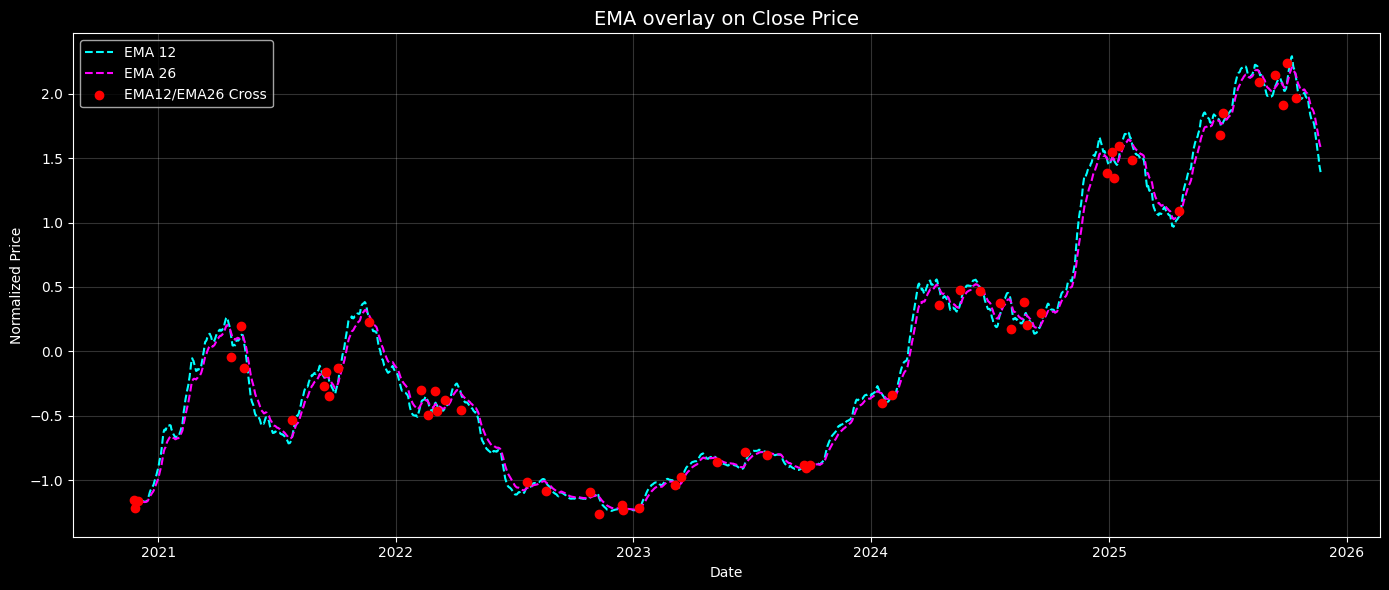

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(data.index):
    data = data.copy()
    data.index = pd.to_datetime(data.index, errors='coerce')
    data = data[~data.index.isna()]

plt.style.use('dark_background')
plt.figure(figsize=(14,6))

# Close price and EMAs
#plt.plot(data.index, data['Close'], label='Close', color='white', linewidth=1.8)
plt.plot(data.index, data['EMA_12'], label='EMA 12', color='cyan', linestyle='--', linewidth=1.5)
plt.plot(data.index, data['EMA_26'], label='EMA 26', color='magenta', linestyle='--', linewidth=1.5)

# EMA12/EMA26 cross points (sign change)
cross_points = data[data['EMA_Signal'] * data['EMA_Signal'].shift(1) < 0]
plt.scatter(cross_points.index, cross_points['Close'], color='red', label='EMA12/EMA26 Cross', zorder=30)

plt.title('EMA overlay on Close Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Create RSI(Relative Strength Index)

In [4]:
def calculate_rsi(prices, window=14):
    """
    Calculate the RSI
    window: number of days to calculate the RSI(e.g. 14)
    """

    #price change
    delta  = prices.diff()

    #gain and loss
    gain = delta.where(delta > 0, 0)
    loss = delta.where(delta < 0, 0)

    #average gain and loss using EMA
    avg_gain = gain.ewm(span=window, adjust=False).mean()
    avg_loss = loss.ewm(span=window, adjust=False).mean()

    #Calculate RS
    rs = avg_gain / -avg_loss.replace(0, 1e-10)

    #Calculate RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

#Create RSI features
data['RSI_14'] = calculate_rsi(data['Close'], 14)
data['RSI_7'] = calculate_rsi(data['Close'], 7)

#RSI-based features
data['RSI_Overbought'] = (data['RSI_14'] > 70).astype(int) # if overbought, 0 otherwise
data['RSI_Oversold'] = (data['RSI_14'] < 30).astype(int) # if oversold, 0 otherwise
data['RSI_Neutral'] = ((data['RSI_14'] >= 30) & (data['RSI_14'] <= 70)).astype(int) # if neutral, 1 otherwise

print('RSI features created')
print(data[['Close', 'RSI_14', 'RSI_7', 'RSI_Overbought', 'RSI_Oversold', 'RSI_Neutral']].head(20))



RSI features created
               Close     RSI_14      RSI_7  RSI_Overbought  RSI_Oversold  \
Price                                                                      
2020-11-22 -1.176306   0.000000   0.000000               0             1   
2020-11-23 -1.176506   0.000000   0.000000               0             1   
2020-11-24 -1.151214  99.319018  99.410148               1             0   
2020-11-25 -1.163985  62.913689  59.552649               0             0   
2020-11-26 -1.217797  22.614146  18.310020               0             1   
2020-11-27 -1.219233  22.176569  17.869512               0             1   
2020-11-28 -1.198511  41.134231  43.850248               0             0   
2020-11-29 -1.182857  51.444290  57.418059               0             0   
2020-11-30 -1.133576  70.324162  78.859788               1             0   
2020-12-01 -1.161573  56.040255  57.085673               0             0   
2020-12-02 -1.148028  60.517085  63.573664               0         

### Plot a graph to display how the different RSI signal variation with time based on the normalized data

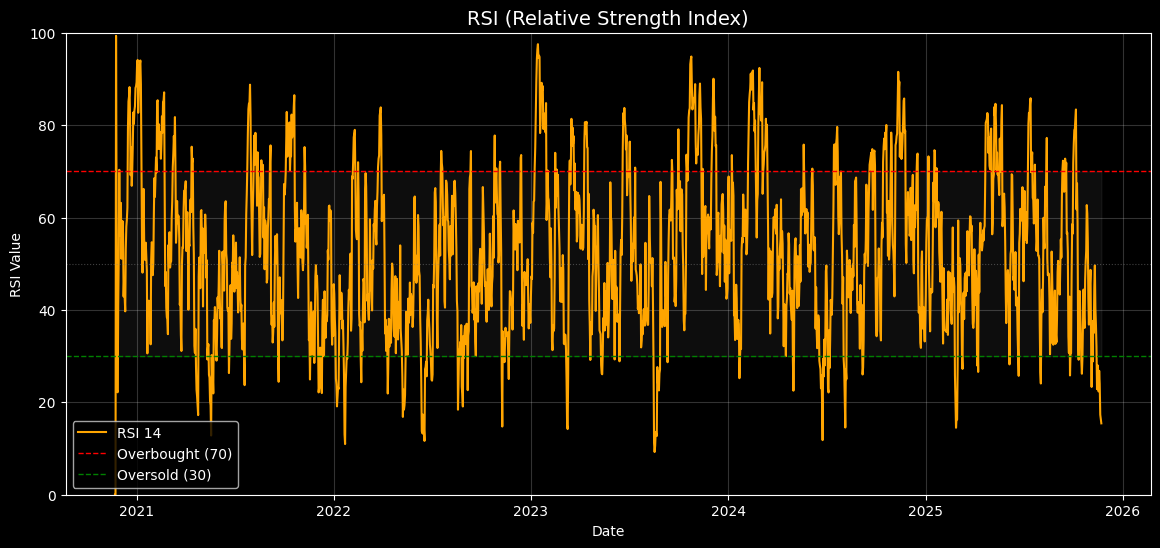

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

if not pd.api.types.is_datetime64_any_dtype(data.index):
   data = data.copy()
   data.index = pd.to_datetime(data.index, errors='coerce')
   data = data[~data.index.isna()]

plt.style.use('dark_background')
plt.figure(figsize=(14, 6))

plt.plot(data.index, data['RSI_14'], label='RSI 14', color='orange', linewidth=1.5)
plt.axhline(y=70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
plt.axhline(y=50, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
plt.fill_between(data.index, 30, 70, alpha=0.1, color='gray')
plt.ylabel('RSI Value')
plt.xlabel('Date')
plt.title('RSI (Relative Strength Index)', fontsize=14)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.2)